In [8]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [10]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [11]:
DATASET_PATH = r"C:\Users\PRANUSH\OneDrive\Desktop\lassy ness ml\archive\data"

print(os.listdir(DATASET_PATH))

['get_info.py', 'labels.txt', 'readme.md', 'split_data.py', 'test', 'train', 'val']


In [16]:
DATASET_PATH = "archive/data"

print(os.listdir(DATASET_PATH))

['get_info.py', 'labels.txt', 'readme.md', 'split_data.py', 'test', 'train', 'val']


In [17]:
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: archive/data\train
Validation: archive/data\val
Test: archive/data\test


In [18]:
print("Train classes:", os.listdir(TRAIN_DIR))
print("Validation classes:", os.listdir(VAL_DIR))
print("Test classes:", os.listdir(TEST_DIR))

Train classes: ['awake', 'sleepy']
Validation classes: ['awake', 'sleepy']
Test classes: ['awake', 'sleepy']


In [20]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

print("Classes:", train_ds.class_names)

Found 50937 files belonging to 2 classes.
Classes: ['awake', 'sleepy']


In [21]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 16980 files belonging to 2 classes.


In [22]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 16981 files belonging to 2 classes.


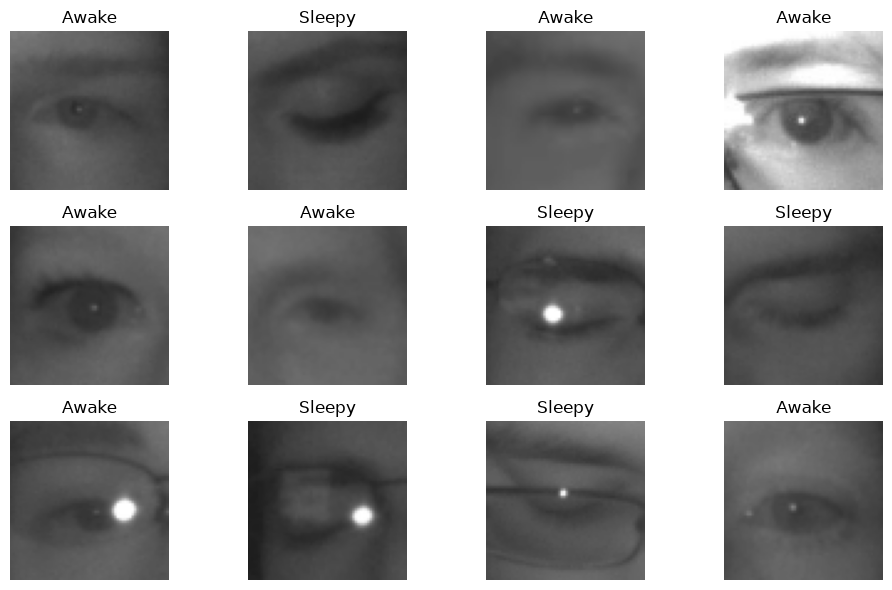

In [24]:
plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i].numpy()[0])

        if label == 0:
            plt.title("Awake")
        else:
            plt.title("Sleepy")

        plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

In [27]:
model = models.Sequential([

    layers.Input(shape=(64, 64, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels
    layers.Rescaling(1./255),

    # CNN Layer 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # CNN Layer 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # CNN Layer 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    # Output
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [29]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


c:\Users\PRANUSH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1592/1592 ━━━━━━━━━━━━━━━━━━━━ 62s 38ms/step - accuracy: 0.9251 - loss: 0.1921 - val_accuracy: 0.9681 - val_loss: 0.0870
Epoch 2/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 58s 36ms/step - accuracy: 0.9664 - loss: 0.0955 - val_accuracy: 0.9723 - val_loss: 0.0765
Epoch 3/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9717 - loss: 0.0800 - val_accuracy: 0.9797 - val_loss: 0.0560
Epoch 4/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.9763 - loss: 0.0686 - val_accuracy: 0.9820 - val_loss: 0.0488
Epoch 5/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.9773 - loss: 0.0642 - val_accuracy: 0.9843 - val_loss: 0.0432
Epoch 6/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.9790 - loss: 0.0615 - val_accuracy: 0.9843 - val_loss: 0.0435
Epoch 7/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.9807 - loss: 0.0567 - val_accuracy: 0.9856 - val_loss: 0.0417
Epoch 8/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.9821 - loss: 0.05

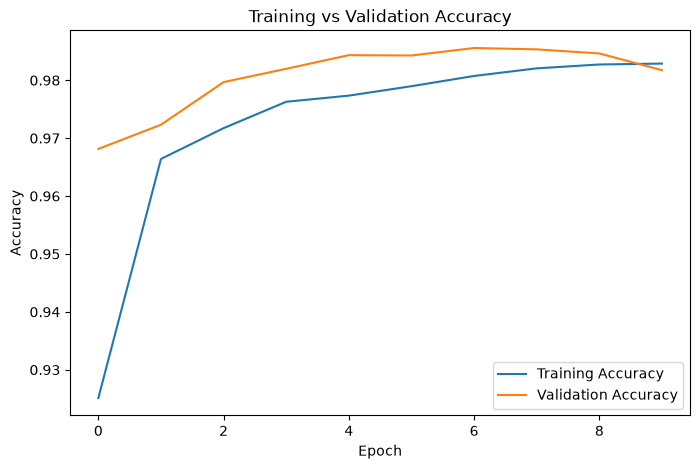

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

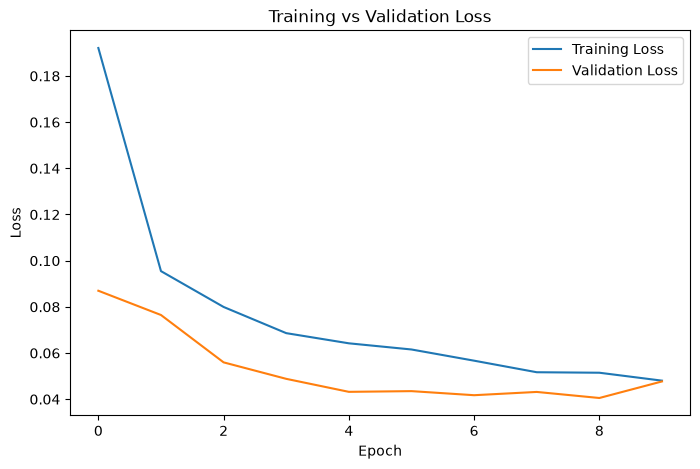

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [32]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

531/531 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.9840 - loss: 0.0455
Test Loss: 0.045476462692022324
Test Accuracy: 0.9839820861816406


In [33]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(predictions)

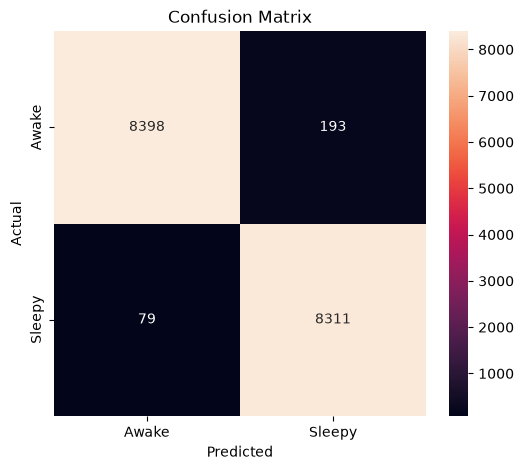

In [34]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Awake", "Sleepy"],
    yticklabels=["Awake", "Sleepy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [35]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Awake", "Sleepy"]
    )
)

              precision    recall  f1-score   support

       Awake       0.99      0.98      0.98      8591
      Sleepy       0.98      0.99      0.98      8390

    accuracy                           0.98     16981
   macro avg       0.98      0.98      0.98     16981
weighted avg       0.98      0.98      0.98     16981



In [46]:
import os

print("Current folder:")
print(os.getcwd())


Current folder:
c:\Users\PRANUSH\OneDrive\Desktop\lassy ness ml


In [47]:
import glob

files = glob.glob("**/s0001_00001_0_0_0_0_01.png", recursive=True)

print(files)

[]


In [51]:
from tensorflow.keras.utils import load_img, img_to_array

image_path = image_path = r"C:\Users\PRANUSH\OneDrive\Desktop\lassy ness ml\archive\data\test\sleepy\s0037_05931_1_1_0_0_0_01.png"

img = load_img(image_path, target_size=IMG_SIZE)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction > 0.5:
    print("😴 SLEEPY")
else:
    print("👁️ AWAKE")

print("Prediction Score:", prediction)

😴 SLEEPY
Prediction Score: 0.9999998


In [52]:
model.save("drowsiness_model.keras")

print("Model saved successfully!")

Model saved successfully!
